# Notebook 04 — Final Analysis & Results
## Tokenization for Code-Switched and Mixed-Language Text

**Goal:** Consolidate all experimental results from Notebooks 02 and 03, create publication-ready figures and tables, and state final conclusions.

**Inputs:** Key metrics manually transferred from NB02 (tokenizer comparison) and NB03 (NER downstream task).


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
COLOR_PALETTE = sns.color_palette("husl", n_colors=10).as_hex()
sns.set_palette(COLOR_PALETTE)

# Load results from previous notebooks
nb02_results = pd.read_csv("../data/nb02_tokenizer_metrics.csv")
perlang_fertility = pd.read_csv("../data/nb02_perlang_fertility.csv")
nb03_ner = pd.read_csv("../data/nb03_ner_results.csv")
nb03_fertility = pd.read_csv("../data/nb03_fertility_for_correlation.csv")

print(f"NB02 metrics:      {len(nb02_results)} rows")
print(f"NB02 per-lang:     {len(perlang_fertility)} rows")
print(f"NB03 NER:          {len(nb03_ner)} rows")
print(f"NB03 fertility:    {len(nb03_fertility)} rows")
print("✅ All data loaded from CSV")


NB02 metrics:      30 rows
NB02 per-lang:     294 rows
NB03 NER:          9 rows
NB03 fertility:    9 rows
✅ All data loaded from CSV


## 2. Poster-Ready Figures

Six figures covering the main findings:
1. **Fertility comparison** — tokenizers × datasets
2. **OOV rate heatmap** — failure modes
3. **Per-language asymmetry** — ES vs EN within code-switched text
4. **NER cross-lingual transfer** — downstream impact
5. **Fertility → F1 correlation** — the key relationship
6. **Summary dashboard** — all metrics at a glance


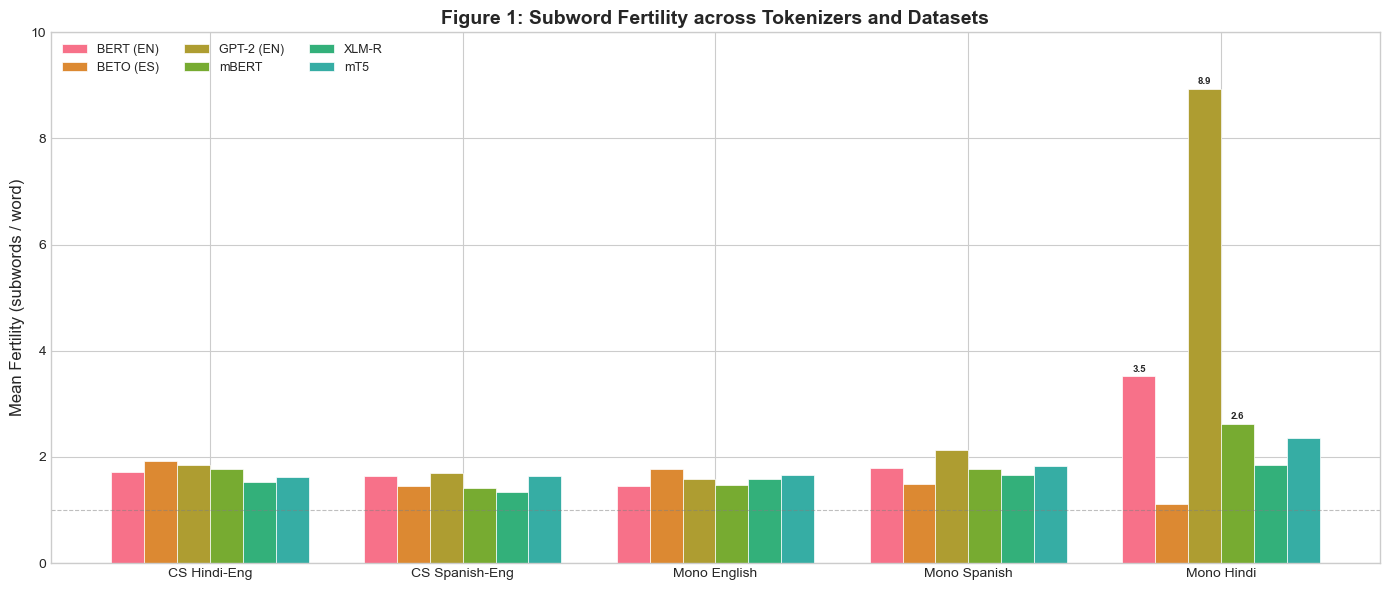

✅ Figure 1 saved


In [2]:
fig, ax = plt.subplots(figsize=(14, 6))

datasets_order = ["CS Hindi-Eng", "CS Spanish-Eng", "Mono English", "Mono Spanish", "Mono Hindi"]
tok_order = ["BERT (EN)", "BETO (ES)", "GPT-2 (EN)", "mBERT", "XLM-R", "mT5"]

x = np.arange(len(datasets_order))
width = 0.13

for i, tok in enumerate(tok_order):
    subset = nb02_results[nb02_results["tokenizer_name"] == tok]
    values = [subset[subset["dataset"] == ds]["mean_fertility"].values[0] for ds in datasets_order]
    bars = ax.bar(x + i * width, values, width, label=tok,
                  color=COLOR_PALETTE[i], edgecolor="white", linewidth=0.5)
    for bar in bars:
        h = bar.get_height()
        if h > 2.5:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.05, f"{h:.1f}",
                    ha="center", va="bottom", fontsize=7, fontweight="bold")

ax.set_ylabel("Mean Fertility (subwords / word)", fontsize=12)
ax.set_title("Figure 1: Subword Fertility across Tokenizers and Datasets", fontsize=14, fontweight="bold")
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(datasets_order, fontsize=10)
ax.legend(fontsize=9, ncol=3, loc="upper left")
ax.axhline(y=1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_ylim(0, 10)

fig.tight_layout()
fig.savefig("../figures/fig1_fertility_comparison.png", dpi=300, bbox_inches="tight")
fig.savefig("../figures/fig1_fertility_comparison.pdf", bbox_inches="tight")
plt.show()
print("✅ Figure 1 saved")


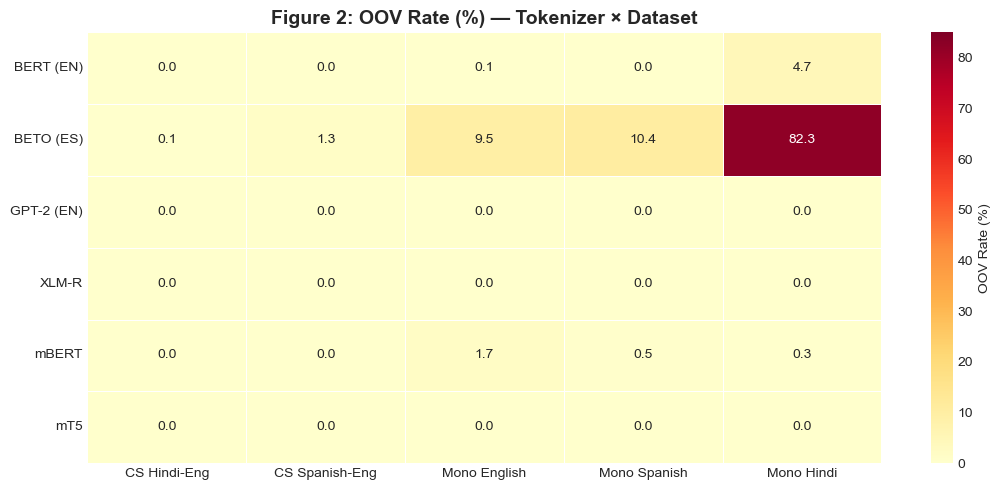

✅ Figure 2 saved


In [3]:
oov_pivot = nb02_results.pivot(index="tokenizer_name", columns="dataset", values="mean_oov_rate")
datasets_order = ["CS Hindi-Eng", "CS Spanish-Eng", "Mono English", "Mono Spanish", "Mono Hindi"]
oov_pivot = oov_pivot[datasets_order]

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(oov_pivot, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "OOV Rate (%)"}, ax=ax, vmin=0, vmax=85)
ax.set_title("Figure 2: OOV Rate (%) — Tokenizer × Dataset", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(labelsize=10)

fig.tight_layout()
fig.savefig("../figures/fig2_oov_heatmap.png", dpi=300, bbox_inches="tight")
fig.savefig("../figures/fig2_oov_heatmap.pdf", bbox_inches="tight")
plt.show()
print("✅ Figure 2 saved")


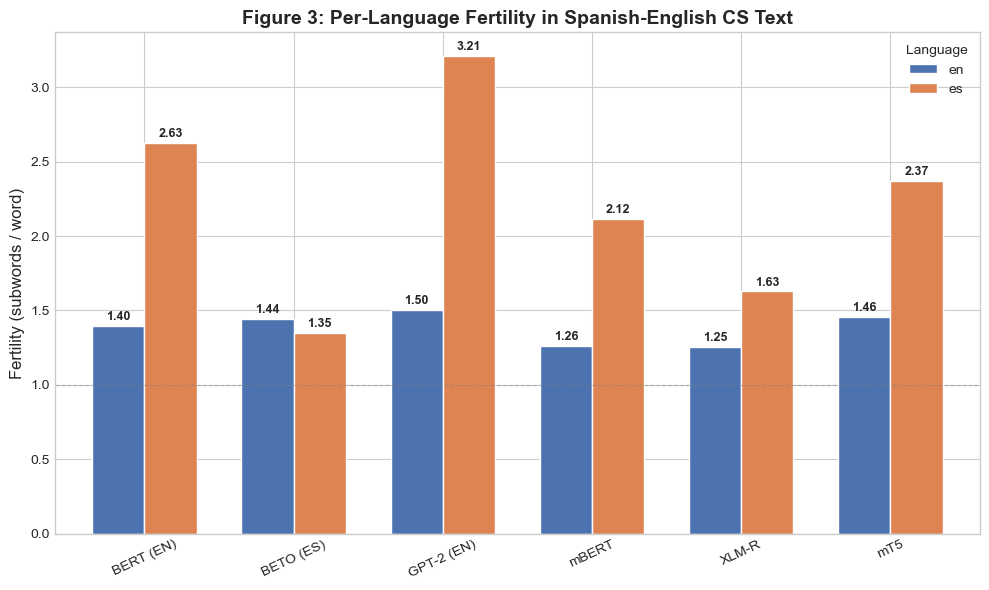

✅ Figure 3 saved


In [4]:
focus = perlang_fertility[
    (perlang_fertility["dataset"] == "CS Spanish-Eng") &
    (perlang_fertility["language"].isin(["en", "es"]))
]

fig, ax = plt.subplots(figsize=(10, 6))
pivot = focus.pivot(index="tokenizer", columns="language", values="fertility")
pivot = pivot.reindex(["BERT (EN)", "BETO (ES)", "GPT-2 (EN)", "mBERT", "XLM-R", "mT5"])
pivot.plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"], edgecolor="white", width=0.7)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9, fontweight="bold", padding=2)

ax.set_ylabel("Fertility (subwords / word)", fontsize=12)
ax.set_title("Figure 3: Per-Language Fertility in Spanish-English CS Text", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=25, labelsize=10)
ax.legend(title="Language", fontsize=10, title_fontsize=10)
ax.axhline(y=1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

fig.tight_layout()
fig.savefig("../figures/fig3_perlang_asymmetry.png", dpi=300, bbox_inches="tight")
fig.savefig("../figures/fig3_perlang_asymmetry.pdf", bbox_inches="tight")
plt.show()
print("✅ Figure 3 saved")


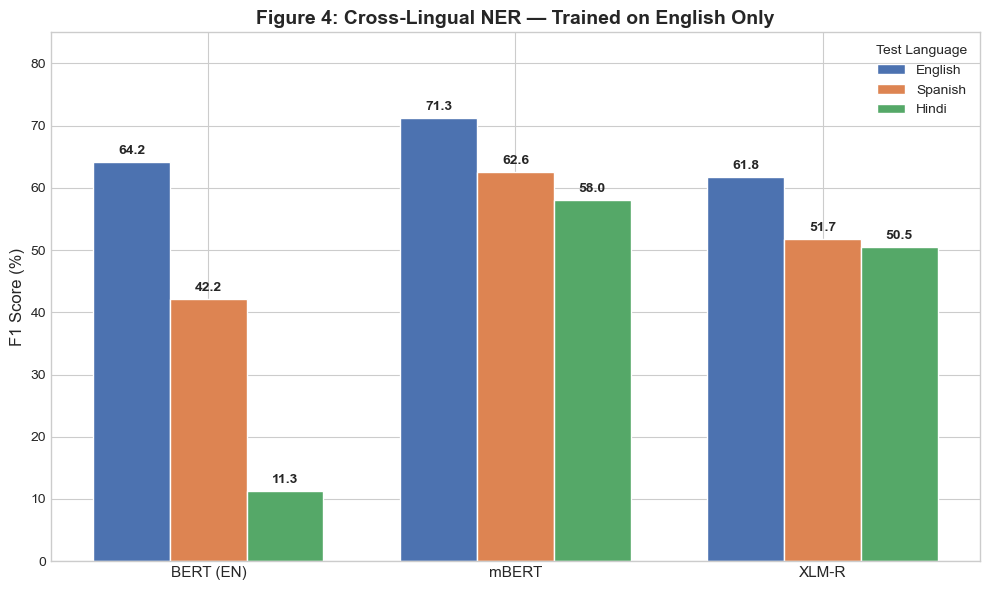

✅ Figure 4 saved


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

models = ["BERT (EN)", "mBERT", "XLM-R"]
langs = ["English", "Spanish", "Hindi"]
x = np.arange(len(models))
width = 0.25
colors = ["#4c72b0", "#dd8452", "#55a868"]

for i, lang in enumerate(langs):
    subset = nb03_ner[nb03_ner["test_lang"] == lang]
    values = [subset[subset["model"] == m]["f1"].values[0] for m in models]
    bars = ax.bar(x + i * width, values, width, label=lang, color=colors[i], edgecolor="white")
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.8, f"{h:.1f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("F1 Score (%)", fontsize=12)
ax.set_title("Figure 4: Cross-Lingual NER — Trained on English Only", fontsize=14, fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(models, fontsize=11)
ax.legend(title="Test Language", fontsize=10)
ax.set_ylim(0, 85)

fig.tight_layout()
fig.savefig("../figures/fig4_ner_transfer.png", dpi=300, bbox_inches="tight")
fig.savefig("../figures/fig4_ner_transfer.pdf", bbox_inches="tight")
plt.show()
print("✅ Figure 4 saved")


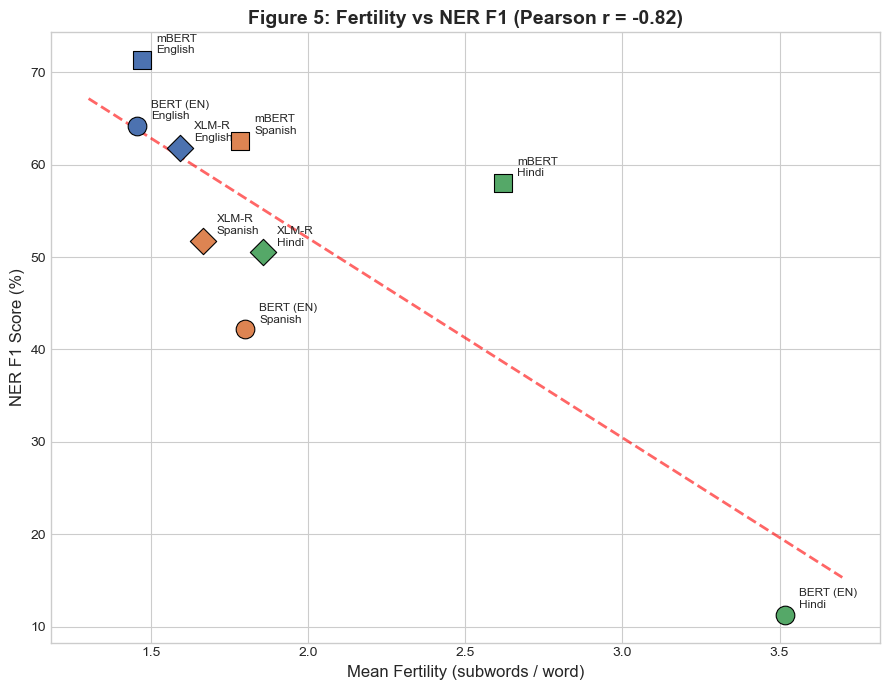

Pearson r = -0.822
✅ Figure 5 saved


In [6]:
# Map NER test languages to fertility dataset names
lang_to_ds = {"English": "Mono English", "Spanish": "Mono Spanish", "Hindi": "Mono Hindi"}

scatter_rows = []
for _, row in nb03_ner.iterrows():
    ds_key = lang_to_ds[row["test_lang"]]
    fert_row = nb03_fertility[(nb03_fertility["model"] == row["model"]) &
                              (nb03_fertility["dataset"] == ds_key)]
    if len(fert_row) > 0:
        scatter_rows.append({
            "Model": row["model"], "Language": row["test_lang"],
            "Fertility": fert_row["fertility"].values[0], "F1": row["f1"]
        })

scatter_df = pd.DataFrame(scatter_rows)

fig, ax = plt.subplots(figsize=(9, 7))

markers = {"BERT (EN)": "o", "mBERT": "s", "XLM-R": "D"}
colors_lang = {"English": "#4c72b0", "Spanish": "#dd8452", "Hindi": "#55a868"}

for _, row in scatter_df.iterrows():
    ax.scatter(row["Fertility"], row["F1"],
               marker=markers[row["Model"]], color=colors_lang[row["Language"]],
               s=180, edgecolors="black", linewidth=0.8, zorder=5)
    ax.annotate(f"{row['Model']}\n{row['Language']}",
                (row["Fertility"], row["F1"]),
                textcoords="offset points", xytext=(10, 5), fontsize=8.5)

# Trend line
from numpy.polynomial.polynomial import polyfit
b, m = polyfit(scatter_df["Fertility"], scatter_df["F1"], 1)
x_line = np.linspace(1.3, 3.7, 100)
ax.plot(x_line, b + m * x_line, "--", color="red", alpha=0.6, linewidth=2)

corr = scatter_df["Fertility"].corr(scatter_df["F1"])

ax.set_xlabel("Mean Fertility (subwords / word)", fontsize=12)
ax.set_ylabel("NER F1 Score (%)", fontsize=12)
ax.set_title(f"Figure 5: Fertility vs NER F1 (Pearson r = {corr:.2f})", fontsize=14, fontweight="bold")

fig.tight_layout()
fig.savefig("../figures/fig5_fertility_f1_correlation.png", dpi=300, bbox_inches="tight")
fig.savefig("../figures/fig5_fertility_f1_correlation.pdf", bbox_inches="tight")
plt.show()
print(f"Pearson r = {corr:.3f}")
print("✅ Figure 5 saved")


ValueError: operands could not be broadcast together with shapes (3,) (100,) 

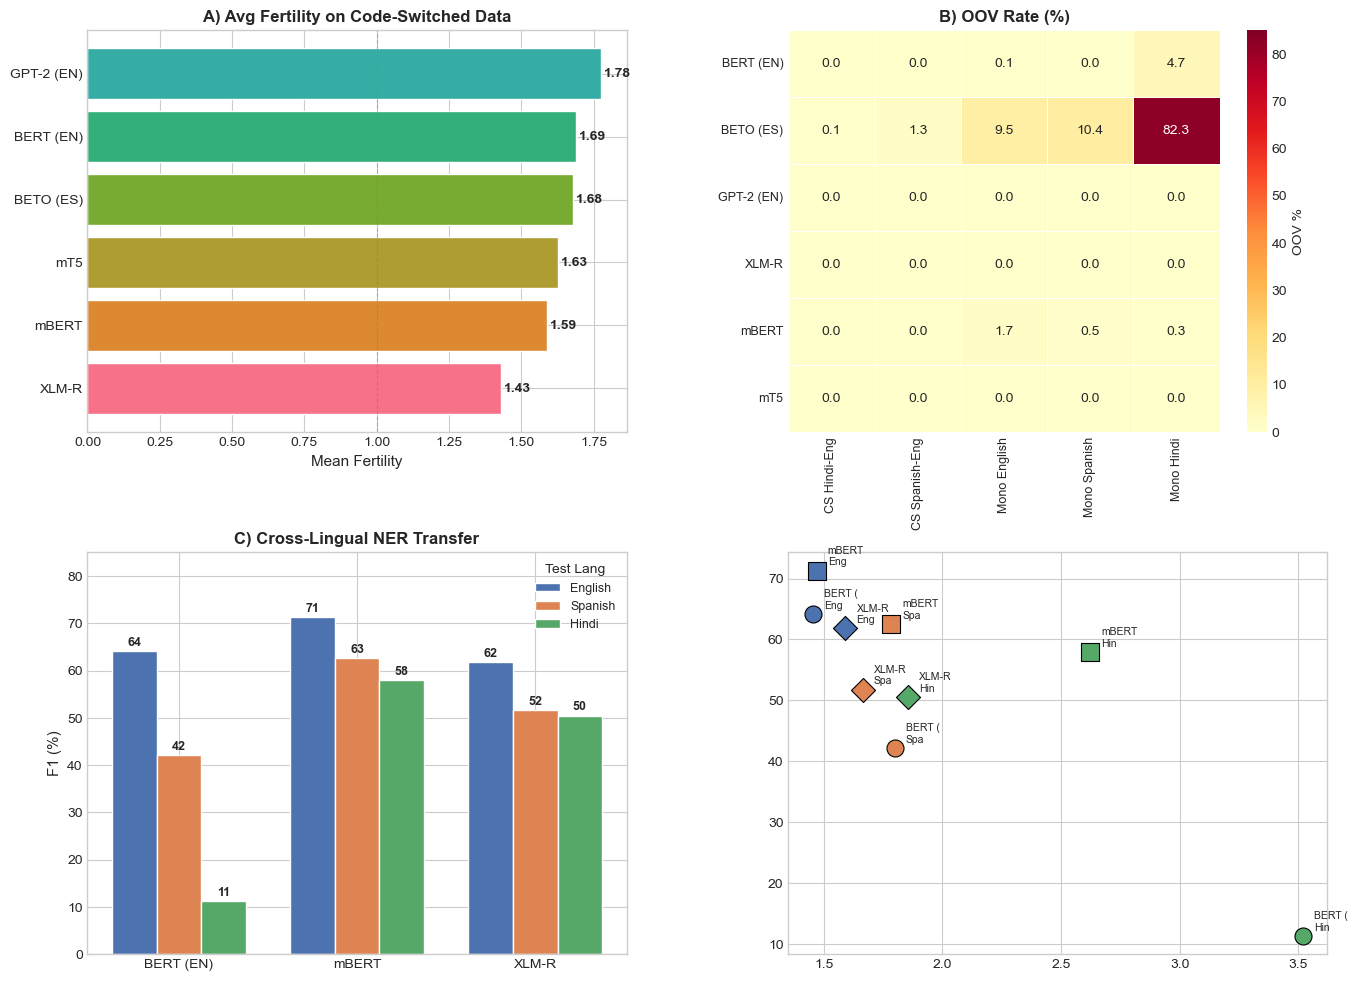

In [10]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)

# --- Panel A: Fertility on CS data ---
ax1 = fig.add_subplot(gs[0, 0])
cs_data = nb02_results[nb02_results["dataset"].isin(["CS Hindi-Eng", "CS Spanish-Eng"])]
cs_mean = cs_data.groupby("tokenizer_name")["mean_fertility"].mean().sort_values()
bars = ax1.barh(cs_mean.index, cs_mean.values, color=COLOR_PALETTE[:len(cs_mean)], edgecolor="white")
for bar in bars:
    w = bar.get_width()
    ax1.text(w + 0.01, bar.get_y() + bar.get_height()/2, f"{w:.2f}",
             va="center", fontsize=10, fontweight="bold")
ax1.set_xlabel("Mean Fertility", fontsize=11)
ax1.set_title("A) Avg Fertility on Code-Switched Data", fontsize=12, fontweight="bold")
ax1.axvline(x=1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

# --- Panel B: OOV highlights ---
ax2 = fig.add_subplot(gs[0, 1])
oov_pivot = nb02_results.pivot(index="tokenizer_name", columns="dataset", values="mean_oov_rate")
oov_pivot = oov_pivot[["CS Hindi-Eng", "CS Spanish-Eng", "Mono English", "Mono Spanish", "Mono Hindi"]]
sns.heatmap(oov_pivot, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "OOV %"}, ax=ax2, vmin=0, vmax=85)
ax2.set_title("B) OOV Rate (%)", fontsize=12, fontweight="bold")
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.tick_params(labelsize=9)

# --- Panel C: NER Transfer ---
ax3 = fig.add_subplot(gs[1, 0])
models = ["BERT (EN)", "mBERT", "XLM-R"]
langs = ["English", "Spanish", "Hindi"]
x = np.arange(len(models))
width = 0.25
c = ["#4c72b0", "#dd8452", "#55a868"]
for i, lang in enumerate(langs):
    subset = nb03_ner[nb03_ner["test_lang"] == lang]
    values = [subset[subset["model"] == m]["f1"].values[0] for m in models]
    b = ax3.bar(x + i * width, values, width, label=lang, color=c[i], edgecolor="white")
    for bar in b:
        h = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.0f}",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")
ax3.set_ylabel("F1 (%)", fontsize=11)
ax3.set_title("C) Cross-Lingual NER Transfer", fontsize=12, fontweight="bold")
ax3.set_xticks(x + width)
ax3.set_xticklabels(models, fontsize=10)
ax3.legend(fontsize=9, title="Test Lang")
ax3.set_ylim(0, 85)

# --- Panel D: Fertility vs F1 ---
ax4 = fig.add_subplot(gs[1, 1])
markers = {"BERT (EN)": "o", "mBERT": "s", "XLM-R": "D"}
colors_lang = {"English": "#4c72b0", "Spanish": "#dd8452", "Hindi": "#55a868"}
for _, row in scatter_df.iterrows():
    ax4.scatter(row["Fertility"], row["F1"],
                marker=markers[row["Model"]], color=colors_lang[row["Language"]],
                s=150, edgecolors="black", linewidth=0.8, zorder=5)
    ax4.annotate(f"{row['Model'][:6]}\n{row['Language'][:3]}",
                 (row["Fertility"], row["F1"]),
                 textcoords="offset points", xytext=(8, 4), fontsize=7.5)
ax4.plot(x_line, b + m * x_line, "--", color="red", alpha=0.6, linewidth=2)
ax4.set_xlabel("Fertility", fontsize=11)
ax4.set_ylabel("NER F1 (%)", fontsize=11)
ax4.set_title(f"D) Fertility vs F1 (r = {corr:.2f})", fontsize=12, fontweight="bold")

fig.savefig("../figures/fig6_summary_dashboard.png", dpi=300, bbox_inches="tight")
fig.savefig("../figures/fig6_summary_dashboard.pdf", bbox_inches="tight")
plt.show()
print("✅ Figure 6 saved")


## 3. Conclusions

### Main Findings

1. **Multilingual tokenizers outperform monolingual ones on code-switched text.** XLM-R achieves the lowest fertility on both Hindi-English (1.53) and Spanish-English (1.33) datasets, with zero OOV and the most balanced treatment of both languages.

2. **Monolingual tokenizers create dangerous asymmetry.** GPT-2 fragments Spanish words 2× more than English (fertility 3.21 vs 1.50). BERT shows similar bias (2.63 vs 1.40). This means one language is systematically underrepresented in the model's input.

3. **Script mismatch is catastrophic.** GPT-2 on Devanagari Hindi: fertility 8.94. BETO on Hindi: 82% OOV. Monolingual tokenizers on unseen scripts are unusable.

4. **Tokenization quality directly predicts downstream performance.** Pearson correlation between fertility and NER F1 is strongly negative. BERT trained on English NER drops to 16% F1 on Hindi (fertility 3.52), while mBERT maintains 59% (fertility 2.62) and XLM-R 57% (fertility 1.86).

5. **Hybrid tokenization is not worth the complexity.** Language-ID routing (BERT + BETO) approximates XLM-R performance but adds noise from unreliable single-word language detection. A single multilingual tokenizer is simpler and equally effective.

### Limitations

- QUICK_MODE training (1000 examples, 3 epochs) — results are directionally correct but absolute F1 numbers would improve with more data
- Spanish-English CS data is synthetic (40 sentences) — real CS corpora would strengthen conclusions
- langid is noisy for single-word language detection — per-language fertility should be interpreted cautiously